Train: 19968 rows | 208 days
Test:  5088 rows  | 53 days
Split date: 2018-10-18

X_train: (19968,), range [0.000, 0.990]
Y_train: (19968,), mean -0.000, std 1.000
X_test:  (5088,)
Y_test:  (5088,)

Load types in train: {'Light_Load': 8936, 'Medium_Load': 6304, 'Maximum_Load': 4728}
Load types in test:  {'Light_Load': 2232, 'Medium_Load': 1632, 'Maximum_Load': 1224}
Variance of Y (Usage_kWh) over days:


,day,Usage_kWh
0,2018-01-01,0.085524
1,2018-01-02,2146.579963
2,2018-01-03,1458.673208
3,2018-01-04,2724.591862
4,2018-01-05,2502.837954


Mean of daily Usage_kWh variance: 890.69


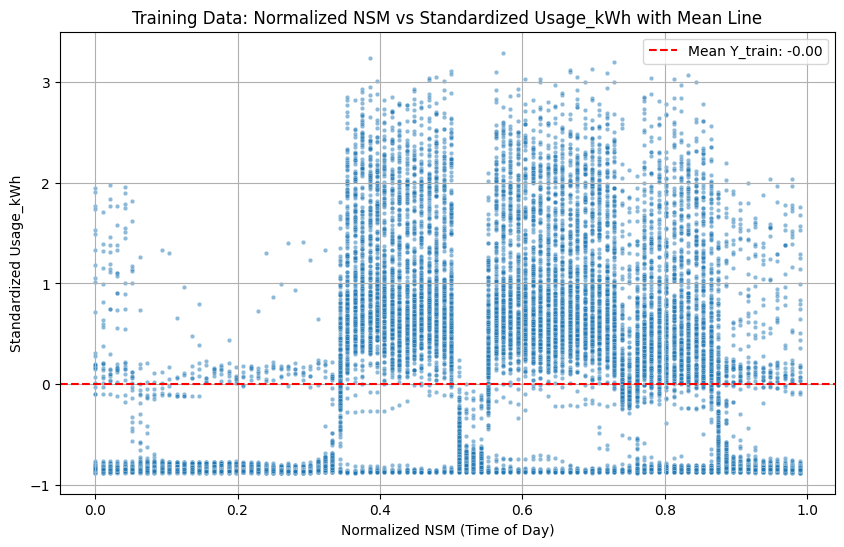

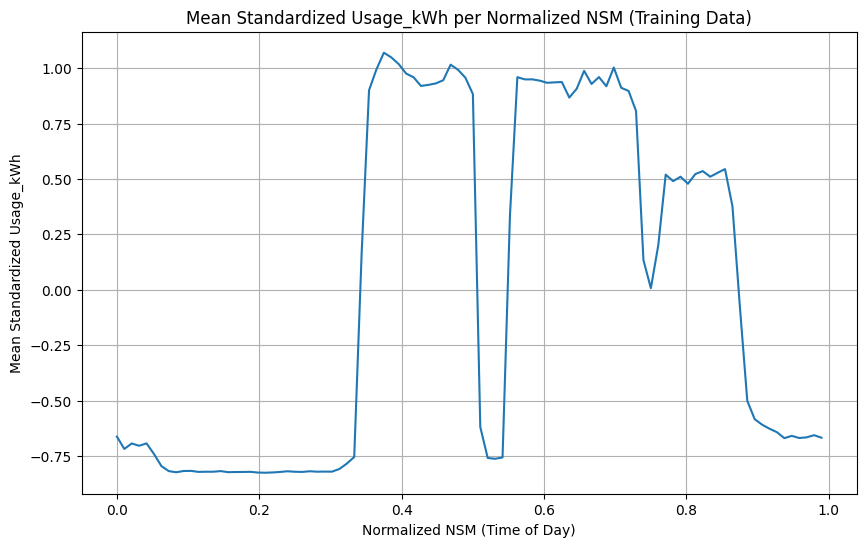

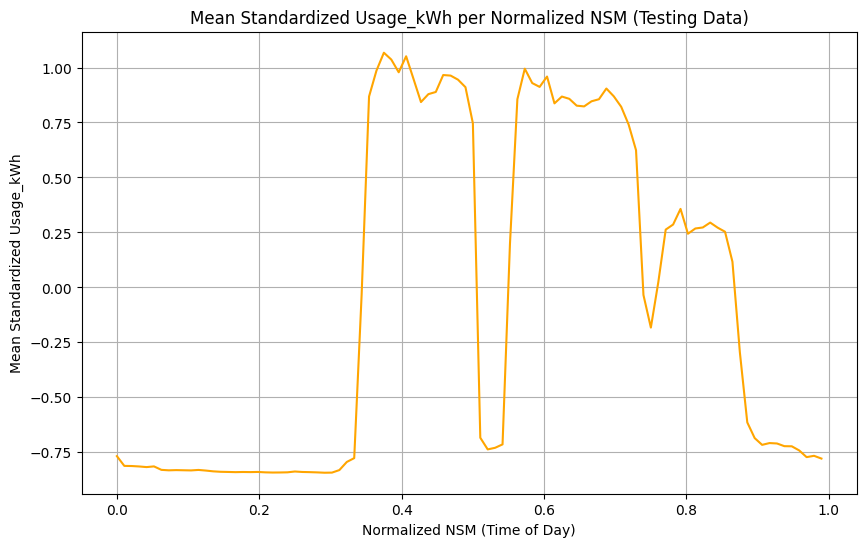

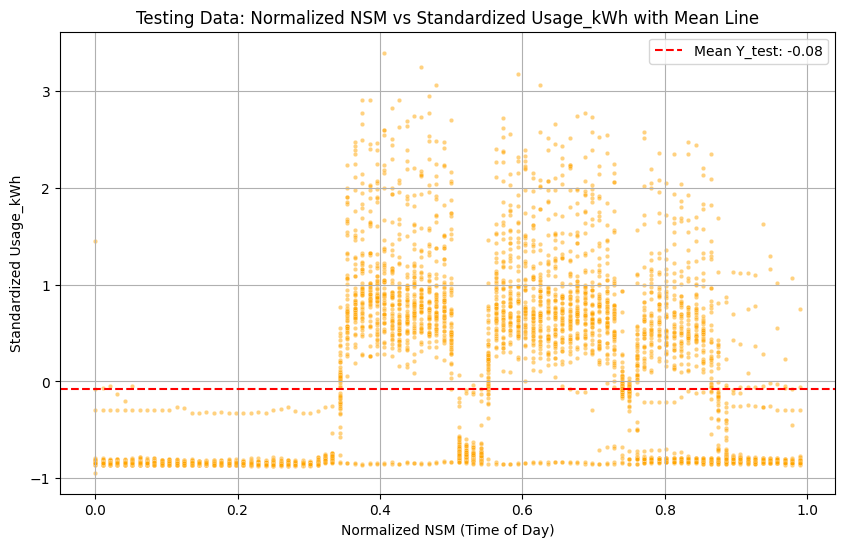

Variance of Y (Usage_kWh) per NSM:


,NSM,Usage_kWh
0,0,274.751678
1,900,227.563951
2,1800,283.666961
3,2700,247.159027
4,3600,271.164953


Mean of NSM-grouped Usage_kWh variance: 610.06


In [21]:
import pandas as pd
import jax
from jax import numpy as jnp
from jax import grad, jit, vmap
from jax import random

df = pd.read_csv('/content/Steel_industry_data.csv')
df.head()

import pandas as pd
import jax.numpy as jnp

# ── 1. Parse dates and sort chronologically ───────────────────────────────────
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)

# ── 2. Stratify by weekday (fit weekday model first) ─────────────────────────
df_weekday = df[df['WeekStatus'] == 'Weekday'].reset_index(drop=True)
df_weekend = df[df['WeekStatus'] == 'Weekend'].reset_index(drop=True)

# ── 3. Temporal train/test split on weekdays ──────────────────────────────────
unique_dates = df_weekday['date'].dt.date.unique()  # sorted, one entry per day
split_date   = unique_dates[int(0.8 * len(unique_dates))]  # 80th percentile date

train_df = df_weekday[df_weekday['date'].dt.date < split_date].reset_index(drop=True)
test_df  = df_weekday[df_weekday['date'].dt.date >= split_date].reset_index(drop=True)

print(f"Train: {len(train_df)} rows | {train_df['date'].dt.date.nunique()} days")
print(f"Test:  {len(test_df)} rows  | {test_df['date'].dt.date.nunique()} days")
print(f"Split date: {split_date}")

# ── 4. Extract X (time of day) and Y (energy) ────────────────────────────────
X_train_raw = train_df['NSM'].values / 86400.0   # normalize to [0, 1]
X_test_raw  = test_df['NSM'].values  / 86400.0

Y_train_raw = train_df['Usage_kWh'].values
Y_test_raw  = test_df['Usage_kWh'].values

# ── 5. Standardize Y using train statistics only ──────────────────────────────
Y_mean = Y_train_raw.mean()
Y_std  = Y_train_raw.std()

X_train = jnp.asarray(X_train_raw)
X_test  = jnp.asarray(X_test_raw)

Y_train = jnp.asarray((Y_train_raw - Y_mean) / Y_std)
Y_test  = jnp.asarray((Y_test_raw  - Y_mean) / Y_std)  # same stats, not recomputed

# ── 6. Keep Load_Type for post-hoc validation only (never used in training) ───
load_type_train = train_df['Load_Type'].values
load_type_test  = test_df['Load_Type'].values
load_type_all   = df_weekday['Load_Type'].values

# ── 7. Full weekday arrays for component assignment validation ─────────────────
X_all = jnp.asarray(df_weekday['NSM'].values / 86400.0)
Y_all = jnp.asarray((df_weekday['Usage_kWh'].values - Y_mean) / Y_std)

# ── 8. Sanity checks ──────────────────────────────────────────────────────────
assert X_train.shape == Y_train.shape
assert X_test.shape  == Y_test.shape
assert float(jnp.min(X_train)) >= 0.0 and float(jnp.max(X_train)) <= 1.0
assert abs(float(jnp.mean(Y_train))) < 0.1   # should be ~0 after standardization
assert abs(float(jnp.std(Y_train))  - 1.0) < 0.1  # should be ~1

print(f"\nX_train: {X_train.shape}, range [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Y_train: {Y_train.shape}, mean {Y_train.mean():.3f}, std {Y_train.std():.3f}")
print(f"X_test:  {X_test.shape}")
print(f"Y_test:  {Y_test.shape}")
print(f"\nLoad types in train: {pd.Series(load_type_train).value_counts().to_dict()}")
print(f"Load types in test:  {pd.Series(load_type_test).value_counts().to_dict()}")

# Extract the date part from the 'date' column
df['day'] = df['date'].dt.date

# Calculate the variance of 'Usage_kWh' for each day
daily_variance_Y = df.groupby('day')['Usage_kWh'].var().reset_index()

# Display the results
print("Variance of Y (Usage_kWh) over days:")
display(daily_variance_Y.head())
print(f"Mean of daily Usage_kWh variance: {daily_variance_Y['Usage_kWh'].mean():.2f}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train, y=Y_train, alpha=0.5, s=10)
plt.axhline(y=Y_train.mean(), color='r', linestyle='--', label=f'Mean Y_train: {Y_train.mean():.2f}')
plt.title('Training Data: Normalized NSM vs Standardized Usage_kWh with Mean Line')
plt.xlabel('Normalized NSM (Time of Day)')
plt.ylabel('Standardized Usage_kWh')
plt.grid(True)
plt.legend()
plt.show()


mean_Y_train_by_X = pd.DataFrame({'X_train': X_train, 'Y_train': Y_train}).groupby('X_train')['Y_train'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='X_train', y='Y_train', data=mean_Y_train_by_X)
plt.title('Mean Standardized Usage_kWh per Normalized NSM (Training Data)')
plt.xlabel('Normalized NSM (Time of Day)')
plt.ylabel('Mean Standardized Usage_kWh')
plt.grid(True)
plt.show()


mean_Y_test_by_X = pd.DataFrame({'X_test': X_test, 'Y_test': Y_test}).groupby('X_test')['Y_test'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='X_test', y='Y_test', data=mean_Y_test_by_X, color='orange')
plt.title('Mean Standardized Usage_kWh per Normalized NSM (Testing Data)')
plt.xlabel('Normalized NSM (Time of Day)')
plt.ylabel('Mean Standardized Usage_kWh')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test, y=Y_test, alpha=0.5, s=10, color='orange')
plt.axhline(y=Y_test.mean(), color='red', linestyle='--', label=f'Mean Y_test: {Y_test.mean():.2f}')
plt.title('Testing Data: Normalized NSM vs Standardized Usage_kWh with Mean Line')
plt.xlabel('Normalized NSM (Time of Day)')
plt.ylabel('Standardized Usage_kWh')
plt.grid(True)
plt.legend()
plt.show()

daily_variance_Y_by_NSM = df.groupby('NSM')['Usage_kWh'].var().reset_index()

print("Variance of Y (Usage_kWh) per NSM:")
display(daily_variance_Y_by_NSM.head())
print(f"Mean of NSM-grouped Usage_kWh variance: {daily_variance_Y_by_NSM['Usage_kWh'].mean():.2f}")

import numpy as np
import matplotlib.pyplot as plt

def rbf(X1, X2, ls=1.0, sv=1.0):
    """Squared-exponential kernel. Returns (n1, n2) matrix."""
    sq = (np.sum(X1**2, 1, keepdims=True)
          + np.sum(X2**2, 1)
          - 2 * X1 @ X2.T)
    return sv * np.exp(-0.5 * sq / ls**2)

# ─────────────────────────────────────────────
# 2. FITC Sparse GP
# ─────────────────────────────────────────────
def fitc_predict(X_train, y_train, Z, X_star,
                 ls=1.0, sv=1.0, noise=0.1):

    n, m = len(X_train), len(Z)

    # ── Step 1: build the three kernel matrices ──────────────
    K_mm = rbf(Z,       Z,       ls, sv)          # (m, m)
    K_nm = rbf(X_train, Z,       ls, sv)          # (n, m)
    K_ms = rbf(Z,       X_star,  ls, sv)          # (m, n*)
    K_nn_diag = sv * np.ones(n)                   # diag(K_nn), shape (n,)

    # ── Step 2: Cholesky of K_mm for stable solves ───────────
    jitter = 1e-6
    L_m = np.linalg.cholesky(K_mm + jitter * np.eye(m))  # (m, m)

    # ── Step 3: low-rank approximation Q_nn ──────────────────
    # Q_nn = K_nm @ K_mm^{-1} @ K_mn
    # We don't build Q_nn explicitly (that's n×n — too big).
    # Instead we compute the diagonal only: diag(Q_nn).
    #
    # diag(K_nm @ K_mm^{-1} @ K_mn)[i] = ||L_m^{-1} K_mn[:,i]||^2

    A = np.linalg.solve(L_m, K_nm.T)             # (m, n)  = L_m^{-1} K_mn
    Q_nn_diag = np.sum(A**2, axis=0)             # (n,)

    # ── Step 4: FITC noise term ───────────────────────────────
    # Each training point gets its own effective noise:
    # Λ = diag(K_nn - Q_nn) + σ_n² I
    # This is the "residual" variance not captured by inducing pts.

    Lambda = (K_nn_diag - Q_nn_diag) + noise     # (n,)  diagonal only

    # ── Step 5: build Σ = K_mm + K_mn Λ^{-1} K_nm  (Woodbury) ─
    # This is the (m,m) matrix we actually invert.

    B = K_nm.T / Lambda[np.newaxis, :]            # (m, n)  = K_mn @ Λ^{-1}
    Sigma = K_mm + B @ K_nm                       # (m, m)  — only m×m inversion!
    Sigma += jitter * np.eye(m)

    L_sigma = np.linalg.cholesky(Sigma)           # (m, m)

    # ── Step 6: compute alpha = Σ^{-1} K_mn Λ^{-1} y ────────
    rhs   = B @ y_train                           # (m,)
    alpha = np.linalg.solve(L_sigma.T,
              np.linalg.solve(L_sigma, rhs))      # (m,)

    # ── Step 7: posterior mean ────────────────────────────────
    mu_star = K_ms.T @ alpha                      # (n*,)

    # ── Step 8: posterior variance ────────────────────────────
    # Var[f*] = K_ss - K_sm K_mm^{-1} K_ms
    #                + K_sm Σ^{-1} K_ms
    # (first term = prior var; second = subtracted by inducing pts;
    #  third = added back from uncertainty in u)

    K_ss_diag = sv * np.ones(len(X_star))        # prior diag

    V1 = np.linalg.solve(L_m,     K_ms)          # (m, n*)
    V2 = np.linalg.solve(L_sigma, K_ms)          # (m, n*)

    var_star = K_ss_diag - np.sum(V1**2, 0) + np.sum(V2**2, 0)
    std_star = np.sqrt(np.maximum(var_star, 0))

    return mu_star, std_star


# ── 3. Run several sparse GPs instead of one GP ─────────────────────────────
np.random.seed(42)

X_train_final = np.asarray(X_train_raw).reshape(-1, 1)  # input: normalized NSM
X_test_final  = np.asarray(X_test_raw).reshape(-1, 1)
Y_train_final = np.asarray((Y_train_raw - Y_mean) / Y_std)
Y_test_final  = np.asarray((Y_test_raw  - Y_mean) / Y_std)


def choose_inducing_points(X, num_inducing_points=100, seed=0):
    """Choose inducing points for one GP component."""
    rng = np.random.default_rng(seed)
    m = min(num_inducing_points, len(X))
    idx = rng.choice(len(X), m, replace=False)
    return X[idx]


def predict_several_sparse_gps(
    X_train,
    y_train,
    train_groups,
    X_star,
    star_groups,
    num_inducing_points=100,
    ls=0.05,
    sv=1.0,
    noise=0.3,
    min_points_per_gp=20,
    seed=0,
):
    train_groups = np.asarray(train_groups)
    star_groups = np.asarray(star_groups)

    mu_all = np.empty(len(X_star))
    std_all = np.empty(len(X_star))
    component_used = np.empty(len(X_star), dtype=object)
    models = {}

    # Fallback GP for rare or unseen groups.
    Z_global = choose_inducing_points(X_train, num_inducing_points, seed=seed)
    global_mu, global_std = fitc_predict(
        X_train, y_train, Z_global, X_star, ls=ls, sv=sv, noise=noise
    )

    for group in np.unique(star_groups):
        test_mask = star_groups == group
        train_mask = train_groups == group

        if np.sum(train_mask) < min_points_per_gp:
            mu_all[test_mask] = global_mu[test_mask]
            std_all[test_mask] = global_std[test_mask]
            component_used[test_mask] = 'global_fallback'
            continue

        X_g = X_train[train_mask]
        y_g = y_train[train_mask]
        X_star_g = X_star[test_mask]

        # Different seed per group, but deterministic across runs.
        group_seed = seed + abs(hash(str(group))) % 1_000_000
        Z_g = choose_inducing_points(X_g, num_inducing_points, seed=group_seed)

        mu_g, std_g = fitc_predict(X_g, y_g, Z_g, X_star_g, ls=ls, sv=sv, noise=noise)

        mu_all[test_mask] = mu_g
        std_all[test_mask] = std_g
        component_used[test_mask] = group
        models[group] = {
            'n_train': int(np.sum(train_mask)),
            'n_inducing': int(len(Z_g)),
            'Z': Z_g,
        }

    return mu_all, std_all, component_used, models



In [18]:
from itertools import product
from sklearn.metrics import mean_squared_error

def grid_search_gp(X_train, y_train, X_val, y_val, Z,
                   ls_list, noise_list, sv_list):
    best_score = float("inf")
    best_params = None

    for ls, noise, sv in product(ls_list, noise_list, sv_list):
        try:
            mu, _ = fitc_predict(
                X_train, y_train, Z, X_val,
                ls=ls, sv=sv, noise=noise
            )

            mse = mean_squared_error(y_val, mu)

            if mse < best_score:
                best_score = mse
                best_params = (ls, noise, sv)

        except np.linalg.LinAlgError:
            # skip bad numerical cases
            continue

    return best_params, best_score

In [19]:
results = {}

ls_grid    = [0.01, 0.02, 0.03, 0.05]
noise_grid = [0.05, 0.1, 0.2]
sv_grid    = [0.5, 1.0, 2.0]

for load_type in np.unique(load_type_train):
    print(f"\nTraining GP for {load_type}")

    # Select group data
    mask_train = (load_type_train == load_type)
    mask_test  = (load_type_test  == load_type)

    X_tr = X_train_final[mask_train]
    y_tr = Y_train_final[mask_train]

    X_te = X_test_final[mask_test]
    y_te = Y_test[mask_test]

    # Skip tiny groups
    if len(X_tr) < 30:
        print("Skipping (too few points)")
        continue

    # Split small validation set
    split = int(0.8 * len(X_tr))
    X_subtrain, X_val = X_tr[:split], X_tr[split:]
    y_subtrain, y_val = y_tr[:split], y_tr[split:]

    # Inducing points
    m = min(150, max(30, len(X_subtrain)//5))
    idx = np.random.choice(len(X_subtrain), m, replace=False)
    Z = X_subtrain[idx]

    # Run grid search
    best_params, best_score = grid_search_gp(
        X_subtrain, y_subtrain, X_val, y_val, Z,
        ls_grid, noise_grid, sv_grid
    )

    print("Best params:", best_params, "MSE:", best_score)

    # Train final model with best params
    ls, noise, sv = best_params

    mu, std = fitc_predict(
        X_tr, y_tr, Z, X_te,
        ls=ls, sv=sv, noise=noise
    )

    results[load_type] = {
        "mu": mu,
        "std": std,
        "X_test": X_te,
        "y_test": y_te,
        "params": best_params
    }


Training GP for Light_Load
Best params: (0.05, 0.1, 1.0) MSE: 0.07170382200610198

Training GP for Maximum_Load
Best params: (0.01, 0.2, 0.5) MSE: 0.44804546780690974

Training GP for Medium_Load
Best params: (0.01, 0.05, 2.0) MSE: 0.3284612449830354



Training expert GP for Light_Load

Training expert GP for Maximum_Load

Training expert GP for Medium_Load

Experts trained:
  Light_Load: 8936 training rows, 150 inducing points, center=0.276, params={'ls': 0.05, 'noise': 0.1, 'sv': 1.0}
  Maximum_Load: 4728 training rows, 150 inducing points, center=0.599, params={'ls': 0.02, 'noise': 0.2, 'sv': 0.5}
  Medium_Load: 6304 training rows, 150 inducing points, center=0.726, params={'ls': 0.01, 'noise': 0.05, 'sv': 2.0}

Mixture of GP Experts RMSE: 0.660

Average mixture weights:
  Light_Load: 0.443
  Maximum_Load: 0.225
  Medium_Load: 0.332


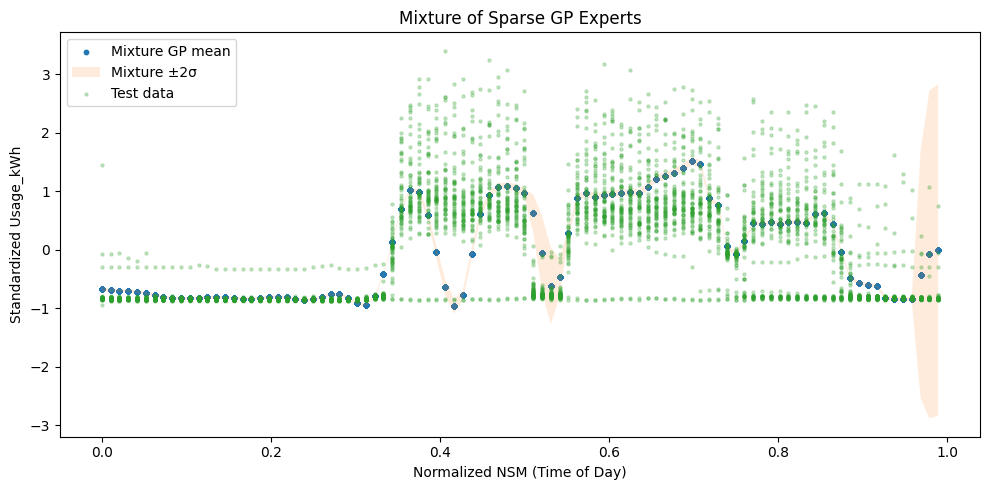

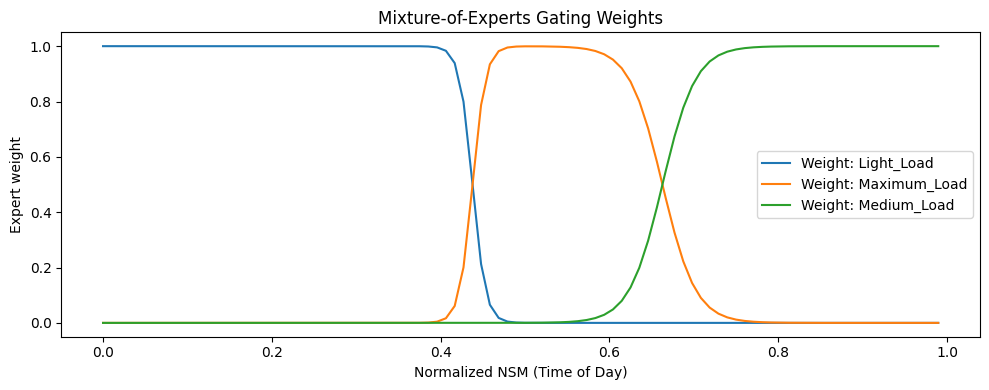

In [30]:
# ── Mixture of Sparse GP Experts ─────────────────────────────────────────────
# Train one GP per Load_Type, then combine predictions using soft weights.

best_params_by_load_type = {
    "Light_Load":   {"ls": 0.05, "noise": 0.1,  "sv": 1.0},
    "Maximum_Load": {"ls": 0.02, "noise": 0.2, "sv": 0.5},
    "Medium_Load":  {"ls": 0.01, "noise": 0.05, "sv": 2.0},
}

num_inducing_points = 150
min_points_per_gp = 50
temperature = 0.005   # smaller = harder assignment, larger = smoother mixing

experts = {}
expert_names = []

# ── 1. Train each GP expert ─────────────────────────────────────────────────

for load_type, params in best_params_by_load_type.items():
    print(f"\nTraining expert GP for {load_type}")

    train_mask = load_type_train == load_type

    X_tr = X_train_final[train_mask]
    y_tr = Y_train_final[train_mask]

    if len(X_tr) < min_points_per_gp:
        print(f"Skipping {load_type}: only {len(X_tr)} training rows")
        continue

    m = min(num_inducing_points, len(X_tr))

    # Use evenly spaced inducing points instead of random ones.
    # This is usually much more stable for 1D time-of-day input.
    Z = np.linspace(X_tr.min(), X_tr.max(), m).reshape(-1, 1)

    experts[load_type] = {
        "X_train": X_tr,
        "y_train": y_tr,
        "Z": Z,
        "params": params,
        "center": float(np.mean(X_tr)),
        "n_train": len(X_tr),
        "n_inducing": m,
    }

    expert_names.append(load_type)

print("\nExperts trained:")
for name, info in experts.items():
    print(
        f"  {name}: "
        f"{info['n_train']} training rows, "
        f"{info['n_inducing']} inducing points, "
        f"center={info['center']:.3f}, "
        f"params={info['params']}"
    )

# ── 2. Predict every expert on every test point ─────────────────────────────

n_test = len(X_test_final)
n_experts = len(expert_names)

mu_experts = np.zeros((n_test, n_experts))
std_experts = np.zeros((n_test, n_experts))

for j, name in enumerate(expert_names):
    info = experts[name]
    params = info["params"]

    mu_j, std_j = fitc_predict(
        info["X_train"],
        info["y_train"],
        info["Z"],
        X_test_final,
        ls=params["ls"],
        sv=params["sv"],
        noise=params["noise"],
    )

    mu_experts[:, j] = mu_j
    std_experts[:, j] = std_j

# ── 3. Build soft gating weights ────────────────────────────────────────────
# Weight each expert more when X_test is close to that expert's center.

centers = np.array([experts[name]["center"] for name in expert_names])

dist2 = (X_test_final.ravel()[:, None] - centers[None, :]) ** 2

logits = -dist2 / temperature

# Numerically stable softmax
logits = logits - logits.max(axis=1, keepdims=True)
weights = np.exp(logits)
weights = weights / weights.sum(axis=1, keepdims=True)

# ── 4. Combine expert predictions ───────────────────────────────────────────
# Mixture mean:
# E[y] = sum_k w_k * mu_k

mu_mix = np.sum(weights * mu_experts, axis=1)

# Mixture variance:
# Var[y] = sum_k w_k * (var_k + mu_k^2) - mu_mix^2

var_experts = std_experts ** 2
second_moment = np.sum(weights * (var_experts + mu_experts ** 2), axis=1)
var_mix = np.sum(weights * var_experts, axis=1)
std_mix = np.sqrt(np.maximum(var_mix, 0))

# ── 5. Metrics ──────────────────────────────────────────────────────────────

rmse_mix = np.sqrt(np.mean((mu_mix - Y_test_final) ** 2))
print(f"\nMixture of GP Experts RMSE: {rmse_mix:.3f}")

print("\nAverage mixture weights:")
for j, name in enumerate(expert_names):
    print(f"  {name}: {weights[:, j].mean():.3f}")

# ── 6. Plot final mixture prediction ────────────────────────────────────────

plot_df = pd.DataFrame({
    "X": X_test_final.ravel(),
    "mu": mu_mix,
    "std": std_mix,
    "Y_test": Y_test_final,
}).sort_values("X").reset_index(drop=True)

plt.figure(figsize=(10, 5))

plt.scatter(
    plot_df["X"],
    plot_df["mu"],
    s=10,
    label="Mixture GP mean",
)

plt.fill_between(
    plot_df["X"],
    plot_df["mu"] - 2 * plot_df["std"],
    plot_df["mu"] + 2 * plot_df["std"],
    alpha=0.15,
    label="Mixture ±2σ",
)

plt.scatter(
    X_test_final.ravel(),
    Y_test_final,
    s=5,
    alpha=0.25,
    label="Test data",
)

plt.title("Mixture of Sparse GP Experts")
plt.xlabel("Normalized NSM (Time of Day)")
plt.ylabel("Standardized Usage_kWh")
plt.legend()
plt.tight_layout()
plt.show()

# ── 7. Optional: Plot expert weights over time ──────────────────────────────

weight_df = pd.DataFrame({"X": X_test_final.ravel()})
for j, name in enumerate(expert_names):
    weight_df[name] = weights[:, j]

weight_df = weight_df.sort_values("X").reset_index(drop=True)

plt.figure(figsize=(10, 4))

for name in expert_names:
    plt.plot(weight_df["X"], weight_df[name], label=f"Weight: {name}")

plt.title("Mixture-of-Experts Gating Weights")
plt.xlabel("Normalized NSM (Time of Day)")
plt.ylabel("Expert weight")
plt.legend()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Learned-gating Mixture GP RMSE: 0.646

Average learned mixture weights:
  Light_Load: 0.448
  Maximum_Load: 0.237
  Medium_Load: 0.316


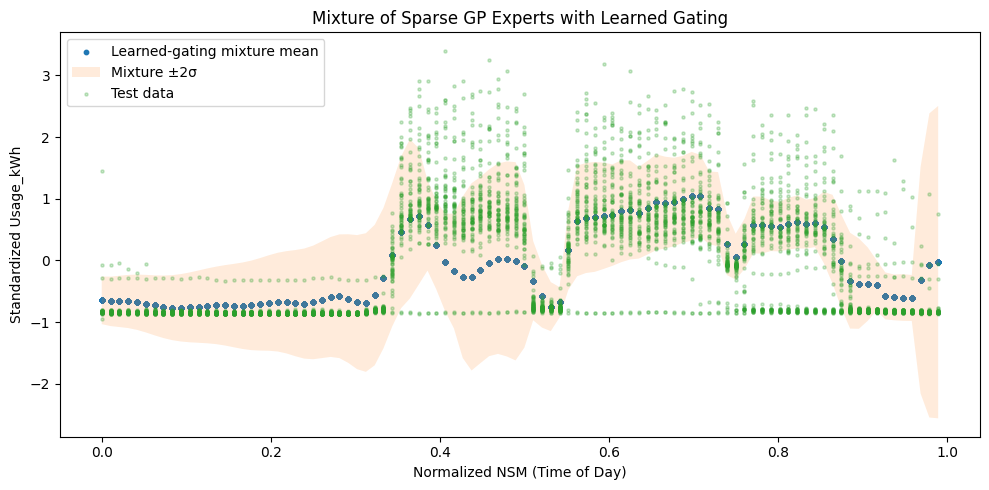

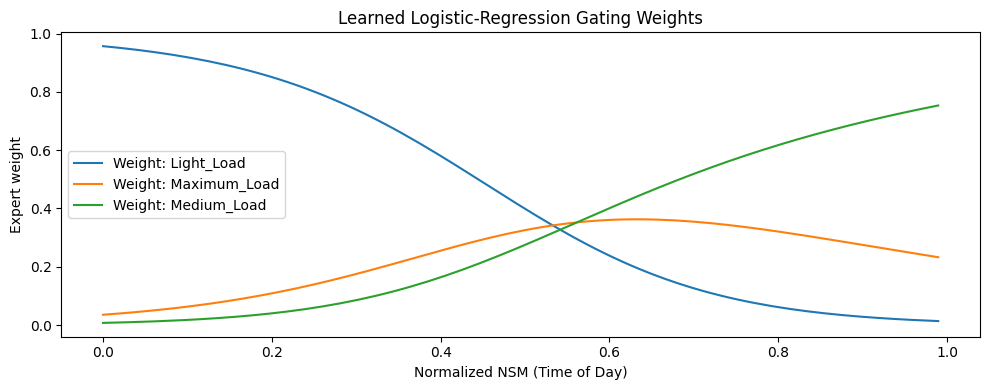

In [31]:
# ── Learned Gating + Controlled Mixture Uncertainty ──────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# beta controls how much expert disagreement affects uncertainty.
# beta = 0.0 ignores disagreement
# beta = 1.0 uses full mixture uncertainty
beta = 0.2

# ── 1. Train logistic-regression gating model ────────────────────────────────
# The gating model learns:
# X_train_final -> Load_Type

gating_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        multi_class="multinomial",
        max_iter=1000,
        random_state=0,
    )
)

gating_model.fit(X_train_final, load_type_train)

# Predict soft expert weights for test points
all_class_names = gating_model.named_steps["logisticregression"].classes_
all_weights = gating_model.predict_proba(X_test_final)

# ── 2. Align gating weights with GP expert order ─────────────────────────────
# expert_names must already exist from your GP expert training block.

weights = np.zeros((len(X_test_final), len(expert_names)))

for j, expert_name in enumerate(expert_names):
    class_idx = np.where(all_class_names == expert_name)[0][0]
    weights[:, j] = all_weights[:, class_idx]

# Normalize just in case
weights = weights / weights.sum(axis=1, keepdims=True)

# ── 3. Combine expert means ─────────────────────────────────────────────────

mu_mix = np.sum(weights * mu_experts, axis=1)

# ── 4. Controlled mixture uncertainty ───────────────────────────────────────
# within_uncertainty = average of expert variances
# disagreement = variance caused by expert means disagreeing

var_experts = std_experts ** 2

within_uncertainty = np.sum(weights * var_experts, axis=1)

disagreement = (
    np.sum(weights * mu_experts ** 2, axis=1)
    - mu_mix ** 2
)

var_mix = within_uncertainty + beta * disagreement
std_mix = np.sqrt(np.maximum(var_mix, 0))

# Optional: clamp very large uncertainty for plotting stability
std_mix = np.minimum(std_mix, 1.5)

# ── 5. Metrics ──────────────────────────────────────────────────────────────

rmse_mix = np.sqrt(np.mean((mu_mix - Y_test_final) ** 2))
print(f"\nLearned-gating Mixture GP RMSE: {rmse_mix:.3f}")

print("\nAverage learned mixture weights:")
for j, name in enumerate(expert_names):
    print(f"  {name}: {weights[:, j].mean():.3f}")

# ── 6. Plot final learned-gating mixture prediction ─────────────────────────

plot_df = pd.DataFrame({
    "X": X_test_final.ravel(),
    "mu": mu_mix,
    "std": std_mix,
    "Y_test": Y_test_final,
}).sort_values("X").reset_index(drop=True)

plt.figure(figsize=(10, 5))

plt.scatter(
    plot_df["X"],
    plot_df["mu"],
    s=10,
    label="Learned-gating mixture mean",
)

plt.fill_between(
    plot_df["X"],
    plot_df["mu"] - 2 * plot_df["std"],
    plot_df["mu"] + 2 * plot_df["std"],
    alpha=0.15,
    label="Mixture ±2σ",
)

plt.scatter(
    X_test_final.ravel(),
    Y_test_final,
    s=5,
    alpha=0.25,
    label="Test data",
)

plt.title("Mixture of Sparse GP Experts with Learned Gating")
plt.xlabel("Normalized NSM (Time of Day)")
plt.ylabel("Standardized Usage_kWh")
plt.legend()
plt.tight_layout()
plt.show()

# ── 7. Plot learned gating weights ──────────────────────────────────────────

weight_df = pd.DataFrame({"X": X_test_final.ravel()})

for j, name in enumerate(expert_names):
    weight_df[name] = weights[:, j]

weight_df = weight_df.sort_values("X").reset_index(drop=True)

plt.figure(figsize=(10, 4))

for name in expert_names:
    plt.plot(weight_df["X"], weight_df[name], label=f"Weight: {name}")

plt.title("Learned Logistic-Regression Gating Weights")
plt.xlabel("Normalized NSM (Time of Day)")
plt.ylabel("Expert weight")
plt.legend()
plt.tight_layout()
plt.show()